# Laboratorio 03 — Fundamentos Estadísticos y Optimización
### Proyectando la Matrícula de Ingeniería de Sistemas
**IS-484 Inteligencia Artificial I · 2026-II**

Este notebook es la **solución comentada** del Laboratorio 03. Cada bloque de código va acompañado de una explicación en markdown de **qué** se calcula y **por qué**, usando los conceptos estadísticos de la semana (estadísticos descriptivos, correlación, función de error, descenso de gradiente/optimización), aplicados siempre al problema real: predecir cuántos alumnos se matricularán en la Escuela de Ingeniería de Sistemas.

## 0. Preparar el entorno

Se importan las librerías que se usarán en todo el notebook: `numpy` y `pandas` para manejar los datos y hacer los cálculos, `matplotlib` para graficar, y `LinearRegression` de `scikit-learn` para la vista previa del modelo completo (Sección 4.5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

%matplotlib inline

## 1. Actividad 4.2 — Explorando el problema: ¿qué influye en la matrícula de cada semestre?

### Parte A: cargar el dataset y conocer las variables

Se carga `matricula_sistemas.csv`, que contiene el historial de 24 semestres (2015-I a 2026-II) de la escuela. Estas son las variables con las que se trabajará **en todo el laboratorio** — las mismas que, más adelante, se usarán para construir el modelo completo:

- `num_postulantes`: cuántos alumnos postularon a la escuela ese semestre.
- `becas_otorgadas`: cuántas becas se otorgaron ese semestre.
- `tasa_desercion_anterior`: qué fracción de alumnos abandonó el semestre previo.
- `campania_difusion`: si hubo (1) o no (0) una campaña de difusión de la escuela.
- `num_matriculados` (**variable objetivo**): cuántos alumnos se matricularon finalmente — esto es lo que se quiere predecir.

In [2]:
matricula = pd.read_csv("matricula_sistemas.csv")
matricula.head()

,semestre,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
0,2015-I,211,10,0.106,0,120
1,2015-II,179,9,0.115,0,88
2,2016-I,180,12,0.150,0,101
3,2016-II,146,8,0.151,0,75
4,2017-I,198,11,0.158,1,112


In [3]:
matricula.describe()

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


`describe()` da un primer vistazo rápido (cuántos datos hay, el promedio, el mínimo, el máximo, etc.), pero para entender bien el comportamiento de la matrícula conviene calcular e interpretar los estadísticos descriptivos uno por uno — eso se hace en la Parte B.

### Parte B: estadísticos descriptivos de la matrícula

Antes de pensar en modelos, conviene entender el comportamiento básico de `num_matriculados`: ¿cuántos alumnos se matriculan en promedio? ¿qué tan dispersa es esa cifra de un semestre a otro? Para responder esto se usan los **estadísticos descriptivos**:

- **Media**: el promedio de todos los semestres.
- **Mediana**: el valor central si se ordenan los 24 semestres de menor a mayor matrícula.
- **Moda**: el valor (o valores) de matrícula que más se repite entre los 24 semestres.
- **Rango**: la diferencia entre el semestre con más matriculados y el que tuvo menos.
- **Varianza** y **desviación estándar**: qué tan dispersos están los datos respecto a la media (la desviación estándar es más fácil de interpretar porque está en la misma unidad que los datos: número de alumnos).

In [4]:
col = matricula["num_matriculados"]

print("Media:", col.mean())
print("Mediana:", col.median())
print("Moda:", col.mode().tolist())
print("Rango:", col.max() - col.min())
print("Varianza:", col.var())
print("Desviacion estandar:", col.std())

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviacion estandar: 34.12243513745971


**Interpretación:** en promedio se matriculan cerca de **137 alumnos** por semestre (la mediana, 137, es casi igual a la media, lo que indica que no hay valores extremos que distorsionen el promedio). La desviación estándar es de aproximadamente **34 alumnos** — es decir, es normal que un semestre tenga bastantes más o menos matriculados que el promedio (de hecho el rango es de 123 alumnos, entre el semestre más bajo con 75 y el más alto con 198). Esa variación de semestre a semestre es justamente lo que se busca explicar con las demás variables del dataset.

### Parte C: correlación — ¿por qué varía la matrícula?

Saber que la matrícula varía no basta — interesa saber **por qué** varía. La **correlación** mide qué tan relacionadas están dos variables, en una escala de $-1$ a $1$: mientras más cerca de $1$ (o de $-1$), más fuerte es la relación. Calcular la correlación de cada variable contra `num_matriculados` indica cuáles conviene usar para predecirla y cuáles aportan poco.

In [5]:
matricula.corr(numeric_only=True)["num_matriculados"]

num_postulantes            0.951145
becas_otorgadas            0.895512
tasa_desercion_anterior   -0.436143
campania_difusion          0.496448
num_matriculados           1.000000
Name: num_matriculados, dtype: float64

**Interpretación:** `num_postulantes` es, por lejos, la variable más correlacionada con la matrícula (≈0.95), seguida de `becas_otorgadas` (≈0.90). Tiene sentido de forma natural: solo pueden matricularse alumnos que antes postularon, así que el número de postulantes es prácticamente la base de donde sale la matrícula — cuando sube, casi siempre sube también el número de matriculados. `tasa_desercion_anterior` tiene una correlación negativa moderada (≈-0.44, más deserción el semestre anterior tiende a asociarse con menor matrícula) y `campania_difusion` una correlación positiva más débil (≈0.50). Estas dos últimas variables influyen, pero de forma más indirecta, sobre qué proporción de los postulantes termina matriculándose.

## 2. Actividad 4.3 — Visualizando la función de error de un modelo real

Ya se sabe que `num_postulantes` es la variable más relacionada con la matrícula. El siguiente paso es ver, de forma visual, qué tan bien o mal predice cada posible valor de la pendiente $w$ — y por qué unos valores son mejores que otros.

Primero se **normaliza** `num_postulantes` (se le resta su media y se divide entre su desviación estándar). Esto no cambia la relación entre las variables, solo pone los números en una escala manejable (típicamente entre -2 y 2 en vez de entre 150 y 310), lo que evita que la curva de error salga con una escala rara y hace que el descenso de gradiente de la siguiente actividad converja de forma estable.

In [6]:
postulantes = matricula["num_postulantes"]
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std()
matriculados = matricula["num_matriculados"].astype(float)

**¿Qué es $w$ (y qué es $b$)?** El modelo que se está construyendo es una recta:
$$\hat{y} = w \cdot x + b$$
donde $x$ es `postulantes_norm` y $\hat{y}$ es la matrícula predicha. Aquí:

- $w$ (la **pendiente**) indica cuánto cambia la matrícula predicha por cada unidad que aumenta `postulantes_norm`. Un $w$ grande significa que la matrícula predicha reacciona fuerte ante cambios en los postulantes; un $w$ cercano a 0 significa que casi no le presta atención a esa variable.
- $b$ (el **intercepto**) es el valor que predice el modelo cuando `postulantes_norm` = 0, es decir, la matrícula base antes de sumar el efecto de los postulantes.

Ninguno de los dos se conoce de antemano: **encontrar los valores de $w$ y $b$ que mejor ajustan los datos es justamente "entrenar" el modelo.** Por eso a continuación se grafica el **error cuadrático medio (MSE)** en función de $w$, dejando el intercepto fijo en $b=137.1$ (su valor óptimo, ya calculado, para poder graficar en dos dimensiones). El MSE mide, en promedio, qué tan lejos está la predicción del valor real de matrícula, elevado al cuadrado: mientras más alto, peor predice ese valor de $w$.

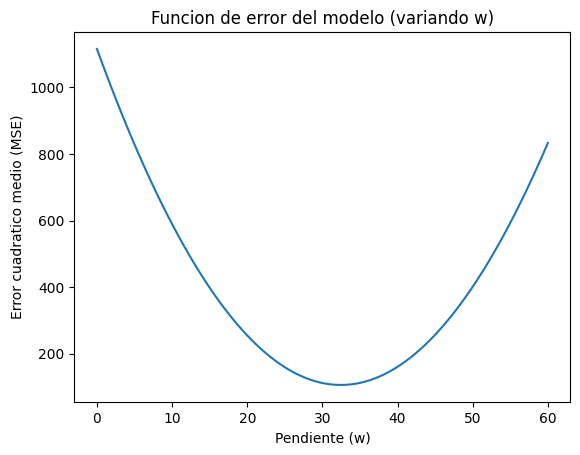

In [7]:
b_fijo = 137.1
valores_w = np.linspace(0, 60, 100)
errores = []

for w in valores_w:
    prediccion = w * postulantes_norm + b_fijo
    mse = np.mean((prediccion - matriculados) ** 2)
    errores.append(mse)

plt.plot(valores_w, errores)
plt.xlabel("Pendiente (w)")
plt.ylabel("Error cuadratico medio (MSE)")
plt.title("Funcion de error del modelo (variando w)")
plt.show()

**Interpretación:** a diferencia de un ejemplo abstracto, esta curva de error es la de un problema real: cada punto representa qué tan mal predeciría la matrícula de los 24 semestres si se usara ese valor de $w$. Se ve claramente una forma de "U": el error es alto en los extremos y tiene un mínimo bien definido alrededor de $w \approx 32$-$33$ — ese es, precisamente, el valor que se busca encontrar matemáticamente en la siguiente actividad.

## 3. Actividad 4.4 — Descenso de gradiente: cómo se entrena un modelo, paso a paso

Elegir $w$ "a ojo" mirando la gráfica no es viable con más variables o más datos — se necesita un método sistemático. El **descenso de gradiente** es exactamente eso: en vez de probar valores al azar, calcula en qué dirección mover $w$ y $b$ para que el error baje lo más rápido posible, y repite ese ajuste paso a paso hasta acercarse al mínimo. Esta es la idea fundamental de **optimización**: encontrar los parámetros que minimizan una función de error.

Se parte de $w=0$, $b=0$ y se dan 10 pasos. En la guía, las dos líneas que actualizan $w$ y $b$ son las que el estudiante debe completar (`# COMPLETAR`); aquí se dejan marcadas con un comentario para que quede claro cuál es exactamente el cálculo que se pide, ya resuelto:

In [8]:
w, b = 0.0, 0.0
tasa_aprendizaje = 0.3
n = len(postulantes_norm)

for paso in range(1, 11):
    prediccion = w * postulantes_norm + b
    error = prediccion - matriculados
    mse = np.mean(error ** 2)

    gradiente_w = (2 / n) * np.sum(error * postulantes_norm)
    gradiente_b = (2 / n) * np.sum(error)

    # COMPLETAR (en la guia): mover w y b en direccion opuesta al
    # gradiente, escalado por la tasa de aprendizaje
    w = w - tasa_aprendizaje * gradiente_w
    b = b - tasa_aprendizaje * gradiente_b

    print(f"Paso {paso}: MSE={mse:.2f}  w={w:.3f}  b={b:.3f}")

Paso 1: MSE=19907.67  w=18.662  b=82.250
Paso 2: MSE=3295.39  w=26.593  b=115.150
Paso 3: MSE=620.37  w=29.964  b=128.310
Paso 4: MSE=189.29  w=31.396  b=133.574
Paso 5: MSE=119.76  w=32.005  b=135.680
Paso 6: MSE=108.53  w=32.264  b=136.522
Paso 7: MSE=106.72  w=32.374  b=136.859
Paso 8: MSE=106.42  w=32.421  b=136.993
Paso 9: MSE=106.37  w=32.441  b=137.047
Paso 10: MSE=106.37  w=32.449  b=137.069


**Interpretación:** en el paso 1 el error (MSE) es enorme, cerca de 19 908, porque $w$ y $b$ empiezan en cero. En cada paso el gradiente le indica al algoritmo hacia dónde moverse, y el error baja rápidamente: para el paso 10 ya se estabiliza en aproximadamente 106.4, y $w$ y $b$ casi no cambian más — eso significa que se llegó al mínimo (o muy cerca de él).

Se comprueba el resultado entrenando, con esta misma variable, un modelo de Scikit-learn:

In [9]:
X_simple = postulantes_norm.values.reshape(-1, 1)
comprobacion = LinearRegression().fit(X_simple, matriculados)
w_sk = round(comprobacion.coef_[0], 2)
b_sk = round(comprobacion.intercept_, 2)
print("Scikit-learn: w =", w_sk, " b =", b_sk)
print("Descenso de gradiente manual: w =", round(w, 2), " b =", round(b, 2))

Scikit-learn: w = 32.46  b = 137.08
Descenso de gradiente manual: w = 32.45  b = 137.07


**Interpretación:** los valores encontrados a mano ($w\approx32.4$, $b\approx137.1$) son prácticamente los mismos que encuentra `LinearRegression` automáticamente. Esto demuestra que no hay ninguna magia dentro de Scikit-learn: `LinearRegression` hace exactamente este mismo cálculo (minimizar el error moviéndose en la dirección del gradiente), solo que de forma automática y, como se verá enseguida, con varias variables a la vez.

## 4. Actividad 4.5 — Vista previa: el modelo completo (contenido de la Semana 5)

**Resumen de lo trabajado hasta aquí:** se calcularon los estadísticos descriptivos de la matrícula y se identificó, con la correlación, que `num_postulantes` es la variable más relacionada (Sección 1); se visualizó la función de error y se encontró su mínimo a mano con descenso de gradiente (Secciones 2 y 3). **Todo esto es contenido propio de la Semana 3.**

A continuación, usando esas mismas cuatro variables introducidas en la Sección 1, se arma el modelo completo: esto es, literalmente, el contenido que se formalizará con su rigor completo en la Semana 5 (separación de datos de entrenamiento y prueba, métricas MAE/RMSE). Aquí basta con ver el resultado.

Un modelo de regresión lineal múltiple predice la matrícula como una combinación de las cuatro variables:
$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + b$$
Scikit-learn encuentra automáticamente los $w_i$ y $b$ que minimizan el error — el mismo tipo de búsqueda que se acaba de hacer a mano, solo que con cuatro variables a la vez:

In [10]:
columnas = ["num_postulantes", "becas_otorgadas",
            "tasa_desercion_anterior", "campania_difusion"]
X = matricula[columnas]
y = matricula["num_matriculados"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Coeficientes:", dict(zip(X.columns, modelo.coef_.round(2))))
print("Intercepto:", round(modelo.intercept_, 2))
print("R2 sobre los datos de entrenamiento:", round(modelo.score(X, y), 3))

Coeficientes: {'num_postulantes': np.float64(0.49), 'becas_otorgadas': np.float64(1.38), 'tasa_desercion_anterior': np.float64(-328.52), 'campania_difusion': np.float64(6.67)}
Intercepto: 37.84
R2 sobre los datos de entrenamiento: 0.953


Y una predicción para un semestre hipotético futuro (2027-I), con 300 postulantes, 30 becas otorgadas, 9% de deserción el semestre anterior y con campaña de difusión activa:

In [11]:
semestre_nuevo = pd.DataFrame([{
    "num_postulantes": 300,
    "becas_otorgadas": 30,
    "tasa_desercion_anterior": 0.09,
    "campania_difusion": 1,
}])

prediccion = modelo.predict(semestre_nuevo)
print("Matricula estimada 2027-I:", round(prediccion[0], 0), "estudiantes")

Matricula estimada 2027-I: 204.0 estudiantes


Para ver qué tan bien ajusta el modelo a los 24 semestres ya conocidos (no solo a un semestre hipotético), se grafica la matrícula real contra la que predice el modelo para esos mismos semestres, junto con una línea diagonal que marcaría una predicción perfecta (si el modelo acertara siempre, cada punto caería exactamente sobre esa línea):

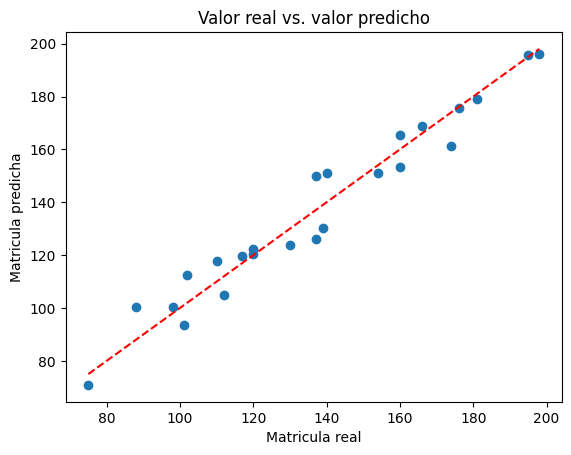

In [12]:
predicciones = modelo.predict(X)

plt.scatter(y, predicciones)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Matricula real")
plt.ylabel("Matricula predicha")
plt.title("Valor real vs. valor predicho")
plt.show()

**Interpretación:** cada punto es un semestre. Mientras más cerca esté de la línea roja (la diagonal), mejor predijo el modelo ese semestre en particular; un punto por encima de la línea significa que el modelo sobreestimó la matrícula real de ese semestre, y uno por debajo significa que la subestimó. En este caso los puntos quedan bastante pegados a la diagonal (el modelo se equivoca, en promedio, por unos 6 alumnos), lo cual es coherente con el $R^2\approx0.95$ calculado arriba: ambos son formas distintas de decir lo mismo, una con un número y otra visualmente. Este tipo de gráfico es, precisamente, el que se usará con su rigor completo en la Semana 5, pero comparando contra datos que el modelo no vio durante el entrenamiento (no como aquí, que se compara contra los mismos datos usados para entrenar).

> **Atención:** esta sección es una vista previa, no se evalúa con el mismo rigor que se usará en la Semana 5: aquí el modelo se entrena y se mide sobre todos los datos a la vez, sin separar entrenamiento y prueba (`train_test_split`, Semana 4), así que su $R^2$ (≈0.95) es optimista. El objetivo aquí es únicamente ver, de forma completa, para qué sirve todo lo trabajado esta semana: con las mismas piezas (correlación, función de error, descenso de gradiente) que se usaron a mano para una sola variable, el modelo completo llega a una predicción concreta de **204 estudiantes** para el próximo semestre.

## 5. Actividad 4.6 — Clasificar casos: regresión, clasificación o clustering

Para cada situación: ¿el aprendizaje sería supervisado o no supervisado?, y ¿el problema corresponde a regresión, clasificación o clustering?

1. **Predecir cuántos estudiantes se matricularán en un semestre futuro (como en esta guía).**
   Supervisado — regresión. Se tienen datos históricos con la respuesta correcta (`num_matriculados`) y lo que se predice es un número continuo.

2. **Detectar si una transacción bancaria es fraudulenta o legítima, usando datos históricos ya etiquetados.**
   Supervisado — clasificación. Los datos ya están etiquetados (fraude / no fraude) y lo que se predice es una categoría, no un número.

3. **Agrupar a los clientes de una tienda en línea según sus hábitos de compra, sin conocer categorías previas.**
   No supervisado — clustering. No hay una respuesta correcta previa; el algoritmo debe descubrir grupos parecidos por sí solo.

4. **Estimar cuántos milisegundos tardará un servidor en responder según su carga de CPU actual.**
   Supervisado — regresión. Se predice un número continuo (milisegundos) a partir de datos históricos con su tiempo de respuesta real registrado.

## 6. Ejercicio Práctico — Consumo eléctrico de un laboratorio

Se repite, de forma independiente y con mayor profundidad, el mismo tipo de análisis: estadísticos descriptivos, correlación y descenso de gradiente. Esta vez sobre un problema distinto: estimar el consumo eléctrico (`consumo_kwh`) de un laboratorio de la universidad a partir de su número de equipos y horas de uso. Además, se compara qué ocurre al usar distintas tasas de aprendizaje.

In [13]:
consumo = pd.read_csv("consumo_laboratorios.csv")
consumo.head()

,num_equipos,horas_uso,consumo_kwh
0,29,5.1,19.6
1,8,6.8,13.3
2,13,3.5,9.8
3,5,7.1,16.0
4,26,6.3,19.7


### Parte A: estadísticos descriptivos

Se calculan media, mediana, moda, rango, varianza y desviación estándar de `num_equipos` y `consumo_kwh`.

In [14]:
for columna in ["num_equipos", "consumo_kwh"]:
    c = consumo[columna]
    print(columna)
    print("  Media:", c.mean())
    print("  Mediana:", c.median())
    print("  Moda:", c.mode().tolist())
    print("  Rango:", c.max() - c.min())
    print("  Varianza:", c.var())
    print("  Desviacion estandar:", c.std())

num_equipos
  Media: 21.416666666666668
  Mediana: 24.5
  Moda: [15, 26]
  Rango: 32
  Varianza: 102.08333333333334
  Desviacion estandar: 10.103629710818451
consumo_kwh
  Media: 16.316666666666666
  Mediana: 17.1
  Moda: [17.1]
  Rango: 13.6
  Varianza: 20.33969696969697
  Desviacion estandar: 4.509955317926883


**Interpretación:** el número de equipos varía bastante entre laboratorios (de 5 a 37, con una desviación estándar de ≈10), y el consumo eléctrico también es disperso (rango de 13.6 kWh, desviación estándar ≈4.5 kWh). Esa dispersión es lo que se intentará explicar con la correlación y, luego, con el modelo.

### Parte B: correlación y selección justificada de variable

In [15]:
consumo.corr(numeric_only=True)["consumo_kwh"]

num_equipos    0.569625
horas_uso      0.580143
consumo_kwh    1.000000
Name: consumo_kwh, dtype: float64

**Justificación de la variable elegida:** `horas_uso` (≈0.58) tiene una correlación apenas mayor que `num_equipos` (≈0.57) con `consumo_kwh` — están muy cerca, así que cualquiera de las dos elecciones es defendible. En este notebook se usa `horas_uso` para el descenso de gradiente de la Parte C, por ser (ligeramente) la más relacionada.

### Parte C: descenso de gradiente y comparación de tasas de aprendizaje

Se define una función reutilizable de descenso de gradiente, y se prueba con dos tasas de aprendizaje distintas: una pequeña (0.05) y una grande (1.2), para ver el efecto de esa elección sobre la optimización. Igual que en la Sección 3, la línea marcada es la que en la guía se deja como `# COMPLETAR`:

In [16]:
variable = consumo["horas_uso"]
variable_norm = (variable - variable.mean()) / variable.std()
consumo_kwh = consumo["consumo_kwh"].astype(float)

def descenso_gradiente(tasa_aprendizaje, pasos=10):
    w, b = 0.0, 0.0
    n = len(variable_norm)
    for paso in range(1, pasos + 1):
        prediccion = w * variable_norm + b
        error = prediccion - consumo_kwh
        mse = np.mean(error ** 2)

        gradiente_w = (2 / n) * np.sum(error * variable_norm)
        gradiente_b = (2 / n) * np.sum(error)

        # COMPLETAR (en la guia): mismo calculo que en la Actividad 4.4,
        # ahora dentro de una funcion reutilizable
        w = w - tasa_aprendizaje * gradiente_w
        b = b - tasa_aprendizaje * gradiente_b
    return w, b, mse

w1, b1, mse1 = descenso_gradiente(tasa_aprendizaje=0.05)
w2, b2, mse2 = descenso_gradiente(tasa_aprendizaje=1.2)
print("tasa=0.05:  w =", round(w1,3), " b =", round(b1,3), " MSE final =", round(mse1,2))
print("tasa=1.2:   w =", round(w2,3), " b =", round(b2,3), " MSE final =", round(mse2,2))

tasa=0.05:  w = 1.616  b = 10.627  MSE final = 53.44
tasa=1.2:   w = -13.584  b = -455.651  MSE final = 113828.93


**Interpretación (Parte D — Reflexión):** con una tasa de aprendizaje muy **pequeña** (0.05), el algoritmo avanza en la dirección correcta, pero da pasos tan chicos que después de 10 pasos todavía está lejos del mínimo (MSE final ≈53, cuando el mínimo real es ≈12). Con una tasa muy **grande** (1.2), los pasos son tan largos que el algoritmo se "pasa" del mínimo una y otra vez, cada vez con más fuerza, y el error termina disparándose a números enormes (MSE final ≈113 829) en vez de bajar — esto se llama **divergencia**.

Esto conecta directamente con la idea de optimización de la Sección 3: encontrar el mínimo de una función de error no es solo cuestión de "moverse en la dirección correcta" (el gradiente ya indica esa dirección), sino también de elegir **qué tan grande** debe ser cada paso. Una tasa de aprendizaje bien elegida (como la 0.3 usada en la Sección 3 de esta guía) logra acercarse al mínimo de forma rápida y estable — ni tan lenta que no llegue a tiempo, ni tan grande que se aleje del mínimo en vez de acercarse.